#  Install Required Packages

In [1]:
# # Run this cell first if packages are not already installed
# 
# !pip install optuna
# !pip install shap
# !pip install scikit-learn
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install joblib
# !pip install lightgbm catboost
# 
# print("✓ All packages installed successfully!")


# Import Libraries

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Advanced optimization
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Explainable AI
import shap

# Model persistence
import joblib

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("CWR PREDICTION MODEL")
print("ML-Based Predictive Irrigation System for Paddy Cultivation")
print("=" * 70)
print("\n✓ All libraries imported successfully!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


CWR PREDICTION MODEL
ML-Based Predictive Irrigation System for Paddy Cultivation

✓ All libraries imported successfully!
Timestamp: 2026-02-24 20:32:57


# Load Dataset

✓ Dataset loaded successfully: Data/paddy_CWR_dataset_20260214_202705.csv

Dataset shape: (4000, 7)
Features: 6
Samples: 4000

First 5 samples:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,3.85,98.7,35.4,9.54,0.48,1,9.72
1,0.00,47.9,31.2,5.39,0.00,5,45.38
2,3.64,97.9,29.1,9.98,2.64,1,8.43
3,0.00,77.7,89.7,4.81,15.74,5,0.00
4,8.66,94.3,17.1,9.54,3.17,4,7.31



Dataset Statistics:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000
mean,4.205855,85.213350,57.290900,6.823190,3.279750,3.00000,26.444840
std,3.611346,14.622071,24.500311,1.725265,4.878442,1.41439,34.461308
min,0.000000,45.200000,15.000000,4.000000,0.000000,1.00000,0.000000
25%,0.110000,75.100000,36.300000,5.500000,0.000000,2.00000,3.000000
50%,4.425000,92.100000,57.400000,6.320000,0.055000,3.00000,12.125000
75%,7.052500,96.100000,78.200000,8.760000,4.992500,4.00000,28.727500
max,12.000000,100.000000,100.000000,10.000000,19.970000,5.00000,120.000000



✓ No missing values detected

CWR Distribution:
  Min:    0.00 mm
  Max:    120.00 mm
  Mean:   26.44 mm
  Median: 12.12 mm
  Std:    34.46 mm


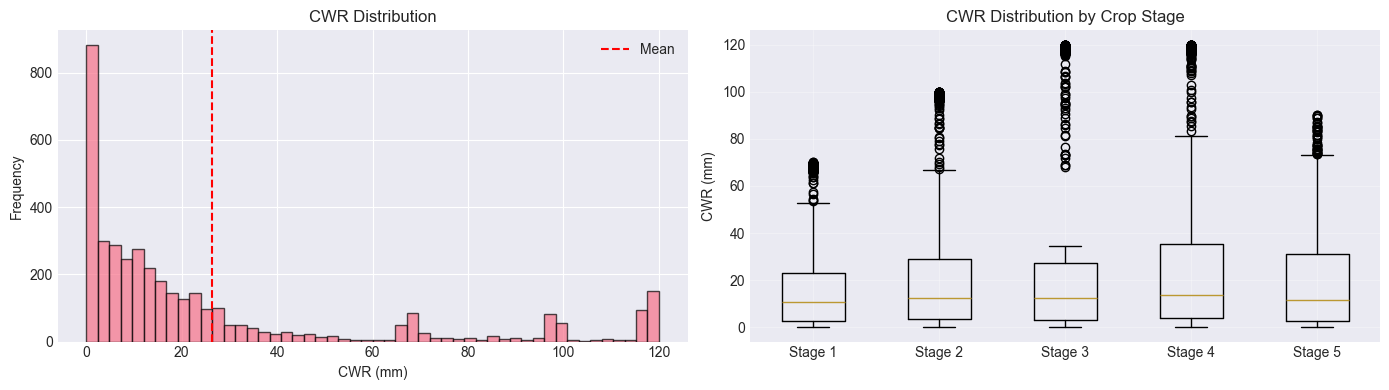

In [3]:
dataset_filename = 'Data/paddy_CWR_dataset_20260214_202705.csv'  # CHANGE THIS TO YOUR FILE

try:
    # Load dataset
    df = pd.read_csv(dataset_filename)
    
    print(f"✓ Dataset loaded successfully: {dataset_filename}")
    print(f"\nDataset shape: {df.shape}")
    print(f"Features: {df.shape[1] - 1}")
    print(f"Samples: {df.shape[0]}")
    
    # Display first few rows
    print("\nFirst 5 samples:")
    display(df.head())
    
    # Basic statistics
    print("\nDataset Statistics:")
    display(df.describe())
    
    # Check for missing values
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("\n✓ No missing values detected")
    else:
        print(f"\nMissing values found:\n{missing[missing > 0]}")
    
    # Check CWR distribution
    print("\nCWR Distribution:")
    print(f"  Min:    {df['CWR_mm'].min():.2f} mm")
    print(f"  Max:    {df['CWR_mm'].max():.2f} mm")
    print(f"  Mean:   {df['CWR_mm'].mean():.2f} mm")
    print(f"  Median: {df['CWR_mm'].median():.2f} mm")
    print(f"  Std:    {df['CWR_mm'].std():.2f} mm")
    
    # Visualize CWR distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].hist(df['CWR_mm'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('CWR (mm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('CWR Distribution')
    axes[0].axvline(df['CWR_mm'].mean(), color='red', linestyle='--', label='Mean')
    axes[0].legend()
    
    axes[1].boxplot([df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],
                    labels=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'])
    axes[1].set_ylabel('CWR (mm)')
    axes[1].set_title('CWR Distribution by Crop Stage')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./Visualisation/dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except FileNotFoundError:
    print(f"ERROR: File '{dataset_filename}' not found!")
    print("Please ensure your dataset file is in the same directory as this notebook.")
    print("Or update the 'dataset_filename' variable with the correct path.")


# Prepare Data for Training

In [4]:
# Separate features (X) and target (y)
feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {list(X.columns)}")

print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Name: {target_column}")

# Split into Train (70%), Validation (15%), Test (15%)
# Use stratified split by crop stage to ensure balanced distribution
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42,
    stratify=df['Crop_Stage']  # Ensure all stages in test set
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=42,
    stratify=X_temp['Crop_Stage']
)

print("\n" + "=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:    {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:  {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:        {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:           {len(X):4d} samples")

# Verify stage distribution
print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in range(1, 6):
    train_count = (X_train['Crop_Stage'] == stage).sum()
    val_count = (X_val['Crop_Stage'] == stage).sum()
    test_count = (X_test['Crop_Stage'] == stage).sum()
    print(f"Stage {stage}   {train_count:>8} {val_count:>8} {test_count:>8}")

print("\nData preparation complete!")

Feature Matrix (X):
  Shape: (4000, 6)
  Features: ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']

Target Variable (y):
  Shape: (4000,)
  Name: CWR_mm

DATA SPLIT SUMMARY
Training set:    2801 samples (70.0%)
Validation set:   599 samples (15.0%)
Test set:         600 samples (15.0%)
Total:           4000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
Stage 1        560      120      120
Stage 2        561      119      120
Stage 3        560      120      120
Stage 4        560      120      120
Stage 5        560      120      120

Data preparation complete!


# Ensemble Stacking with Hyperparameter Optimization

In [5]:
# Cell 5: ENSEMBLE STACKING WITH OPTIMIZED BASE MODELS
import time
print("=" * 70)
print("METHOD 1: ENSEMBLE STACKING WITH HYPERPARAMETER OPTIMIZATION")
print("=" * 70)
print("\nTraining and optimizing 5 diverse models, then stacking the best 3")
print("to achieve superior prediction accuracy.\n")

# ============================================================================
# STEP 1: Define All 5 Base Models (Default Parameters)
# ============================================================================

print("STEP 1: Creating 5 Base Models")
print("-" * 70)

all_base_models = [
    ('random_forest', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
    
    ('gradient_boosting', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )),
    
    ('xgboost', XGBRegressor(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )),
    
    ('lightgbm', LGBMRegressor(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )),
    
    ('catboost', CatBoostRegressor(
        iterations=150,
        depth=6,
        learning_rate=0.1,
        random_seed=42,
        verbose=False
    ))
]

print(f"Created {len(all_base_models)} diverse base models:")
for name, model in all_base_models:
    print(f"  • {name}: {type(model).__name__}")

METHOD 1: ENSEMBLE STACKING WITH HYPERPARAMETER OPTIMIZATION

Training and optimizing 5 diverse models, then stacking the best 3
to achieve superior prediction accuracy.

STEP 1: Creating 5 Base Models
----------------------------------------------------------------------
Created 5 diverse base models:
  • random_forest: RandomForestRegressor
  • gradient_boosting: GradientBoostingRegressor
  • xgboost: XGBRegressor
  • lightgbm: LGBMRegressor
  • catboost: CatBoostRegressor


In [6]:
# ============================================================================
# STEP 2: Hyperparameter Optimization for All 5 Models
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: Bayesian Hyperparameter Optimization (All Models)")
print("=" * 70)
print("\nOptimizing each model independently using Optuna TPE sampler")

optuna.logging.set_verbosity(optuna.logging.WARNING)

optimized_params = {}
optimization_times = {}

# 2.1: Optimize Random Forest
print("-" * 70)
print("Optimizing Random Forest (1/5)...")
print("-" * 70)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=25),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    return cv_scores.mean()

start_time = time.time()
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)
optimization_times['random_forest'] = time.time() - start_time
optimized_params['random_forest'] = study_rf.best_params
print(f"Best MAE: {-study_rf.best_value:.3f} mm | Time: {optimization_times['random_forest']:.1f}s")

# 2.2: Optimize Gradient Boosting
print("\n" + "-" * 70)
print("Optimizing Gradient Boosting (2/5)...")
print("-" * 70)

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    return cv_scores.mean()

start_time = time.time()
study_gb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=50, show_progress_bar=True)
optimization_times['gradient_boosting'] = time.time() - start_time
optimized_params['gradient_boosting'] = study_gb.best_params
print(f"Best MAE: {-study_gb.best_value:.3f} mm | Time: {optimization_times['gradient_boosting']:.1f}s")

# 2.3: Optimize XGBoost
print("\n" + "-" * 70)
print("Optimizing XGBoost (3/5)...")
print("-" * 70)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    return cv_scores.mean()

start_time = time.time()
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
optimization_times['xgboost'] = time.time() - start_time
optimized_params['xgboost'] = study_xgb.best_params
print(f"Best MAE: {-study_xgb.best_value:.3f} mm | Time: {optimization_times['xgboost']:.1f}s")

# 2.4: Optimize LightGBM
print("\n" + "-" * 70)
print("Optimizing LightGBM (4/5)...")
print("-" * 70)

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    return cv_scores.mean()

start_time = time.time()
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)
optimization_times['lightgbm'] = time.time() - start_time
optimized_params['lightgbm'] = study_lgb.best_params
print(f"Best MAE: {-study_lgb.best_value:.3f} mm | Time: {optimization_times['lightgbm']:.1f}s")

# 2.5: Optimize CatBoost
print("\n" + "-" * 70)
print("Optimizing CatBoost (5/5)...")
print("-" * 70)

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 250),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
    }
    model = CatBoostRegressor(**params, random_seed=42, verbose=False)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5,
                                scoring='neg_mean_absolute_error', n_jobs=-1)
    return cv_scores.mean()

start_time = time.time()
study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)
optimization_times['catboost'] = time.time() - start_time
optimized_params['catboost'] = study_cat.best_params
print(f"Best MAE: {-study_cat.best_value:.3f} mm | Time: {optimization_times['catboost']:.1f}s")

print("\n" + "=" * 70)
print("Hyperparameter Optimization Complete")
print("=" * 70)


STEP 2: Bayesian Hyperparameter Optimization (All Models)

Optimizing each model independently using Optuna TPE sampler
----------------------------------------------------------------------
Optimizing Random Forest (1/5)...
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 1.181 mm | Time: 44.1s

----------------------------------------------------------------------
Optimizing Gradient Boosting (2/5)...
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 0.848 mm | Time: 42.1s

----------------------------------------------------------------------
Optimizing XGBoost (3/5)...
----------------------------------------------------------------------


...

Best MAE: 1.071 mm | Time: 14.1s

----------------------------------------------------------------------
Optimizing LightGBM (4/5)...
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 0.994 mm | Time: 81.9s

----------------------------------------------------------------------
Optimizing CatBoost (5/5)...
----------------------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

Best MAE: 0.891 mm | Time: 126.2s

Hyperparameter Optimization Complete


In [7]:
# ============================================================================
# STEP 3: Train All 5 Models with Optimized Parameters
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: Training All Models with Optimized Parameters")
print("=" * 70)

optimized_models = {}
model_scores = {}

# Train Random Forest
print("\nTraining optimized Random Forest...")
optimized_models['random_forest'] = RandomForestRegressor(
    **optimized_params['random_forest'], random_state=42, n_jobs=-1
)
optimized_models['random_forest'].fit(X_train, y_train)
y_val_pred = optimized_models['random_forest'].predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
model_scores['random_forest'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R2: {r2:.4f}")

# Train Gradient Boosting
print("\nTraining optimized Gradient Boosting...")
optimized_models['gradient_boosting'] = GradientBoostingRegressor(
    **optimized_params['gradient_boosting'], random_state=42
)
optimized_models['gradient_boosting'].fit(X_train, y_train)
y_val_pred = optimized_models['gradient_boosting'].predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
model_scores['gradient_boosting'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R2: {r2:.4f}")

# Train XGBoost
print("\nTraining optimized XGBoost...")
optimized_models['xgboost'] = XGBRegressor(
    **optimized_params['xgboost'], random_state=42, n_jobs=-1
)
optimized_models['xgboost'].fit(X_train, y_train)
y_val_pred = optimized_models['xgboost'].predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
model_scores['xgboost'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R2: {r2:.4f}")

# Train LightGBM
print("\nTraining optimized LightGBM...")
optimized_models['lightgbm'] = LGBMRegressor(
    **optimized_params['lightgbm'], random_state=42, n_jobs=-1, verbose=-1
)
optimized_models['lightgbm'].fit(X_train, y_train)
y_val_pred = optimized_models['lightgbm'].predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
model_scores['lightgbm'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R2: {r2:.4f}")

# Train CatBoost
print("\nTraining optimized CatBoost...")
optimized_models['catboost'] = CatBoostRegressor(
    **optimized_params['catboost'], random_seed=42, verbose=False
)
optimized_models['catboost'].fit(X_train, y_train)
y_val_pred = optimized_models['catboost'].predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)
model_scores['catboost'] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R2: {r2:.4f}")


STEP 3: Training All Models with Optimized Parameters

Training optimized Random Forest...
MAE: 1.048 mm | RMSE: 1.866 mm | R2: 0.9970

Training optimized Gradient Boosting...
MAE: 0.753 mm | RMSE: 1.218 mm | R2: 0.9987

Training optimized XGBoost...
MAE: 1.010 mm | RMSE: 1.836 mm | R2: 0.9971

Training optimized LightGBM...
MAE: 0.834 mm | RMSE: 1.541 mm | R2: 0.9980

Training optimized CatBoost...
MAE: 0.786 mm | RMSE: 1.408 mm | R2: 0.9983


In [8]:
# ============================================================================
# STEP 4: Select Best 3 Models
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: Model Selection (Best 3)")
print("=" * 70)

# Sort models by MAE
scores_df = pd.DataFrame(model_scores).T.sort_values('MAE')
print("\nAll Models Ranked by Validation MAE:")
print(scores_df.to_string())

# Select top 3
best_3_names = scores_df.head(3).index.tolist()
print(f"\nSelected Best 3 Models for Stacking:")
for i, name in enumerate(best_3_names, 1):
    print(f"  {i}. {name}: MAE = {model_scores[name]['MAE']:.3f} mm")

# Create base_models list for stacking
base_models = [(name, optimized_models[name]) for name in best_3_names]


STEP 4: Model Selection (Best 3)

All Models Ranked by Validation MAE:
                        MAE      RMSE        R2
gradient_boosting  0.752617  1.218002  0.998730
catboost           0.786483  1.407622  0.998303
lightgbm           0.833572  1.541290  0.997966
xgboost            1.009620  1.836458  0.997112
random_forest      1.047840  1.866317  0.997017

Selected Best 3 Models for Stacking:
  1. gradient_boosting: MAE = 0.753 mm
  2. catboost: MAE = 0.786 mm
  3. lightgbm: MAE = 0.834 mm


In [9]:
# ============================================================================
# STEP 5: Build and Train Stacking Ensemble
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: Building Stacking Ensemble with Best 3 Models")
print("=" * 70)

# Meta-learner
meta_model = Ridge(alpha=0.5, random_state=42)

# Create stacking regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    verbose=0
)

print("Stacking Configuration:")
print(f"  Base Models: {len(base_models)}")
for name, _ in base_models:
    print(f"    • {name}")
print(f"  Meta-Learner: {type(meta_model).__name__}")
print(f"  CV Folds: 5")

print("\nTraining Stacking Ensemble...")
print("(This may take 2-3 minutes...)")

start_time = time.time()
stacking_model.fit(X_train, y_train)
training_time = time.time() - start_time
print(f"Training complete in {training_time:.1f} seconds")


STEP 5: Building Stacking Ensemble with Best 3 Models
Stacking Configuration:
  Base Models: 3
    • gradient_boosting
    • catboost
    • lightgbm
  Meta-Learner: Ridge
  CV Folds: 5

Training Stacking Ensemble...
(This may take 2-3 minutes...)
Training complete in 9.7 seconds


In [10]:
# ============================================================================
# STEP 6: Evaluate Stacking Ensemble
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: Evaluation Results")
print("=" * 70)

# Predictions
y_train_pred_stack = stacking_model.predict(X_train)
y_val_pred_stack = stacking_model.predict(X_val)
y_test_pred_stack = stacking_model.predict(X_test)

# Calculate metrics
def evaluate_predictions(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Set:")
    print(f"  MAE:  {mae:.3f} mm")
    print(f"  RMSE: {rmse:.3f} mm")
    print(f"  R2:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

train_metrics = evaluate_predictions(y_train, y_train_pred_stack, "Training")
val_metrics = evaluate_predictions(y_val, y_val_pred_stack, "Validation")
test_metrics = evaluate_predictions(y_test, y_test_pred_stack, "Test")


STEP 6: Evaluation Results

Training Set:
  MAE:  0.245 mm
  RMSE: 0.334 mm
  R2:   0.9999

Validation Set:
  MAE:  0.631 mm
  RMSE: 0.997 mm
  R2:   0.9991

Test Set:
  MAE:  0.641 mm
  RMSE: 1.134 mm
  R2:   0.9989


In [20]:
# ============================================================================
# STEP 7: Final comparison
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON: Stacking vs Individual Models")
print("=" * 70)

# Add stacking results
model_scores['STACKING_ENSEMBLE'] = val_metrics

# Create comparison dataframe
comparison_df = pd.DataFrame(model_scores).T
comparison_df = comparison_df.sort_values('MAE')

print("\nValidation Set Performance (sorted by MAE):")
print(comparison_df.to_string())

# Calculate improvement
best_individual_mae = comparison_df.iloc[1]['MAE']
stacking_mae = comparison_df.iloc[0]['MAE']
improvement = ((best_individual_mae - stacking_mae) / best_individual_mae) * 100

print(f"\nStacking Ensemble Improvement: {improvement:.2f}% better than best individual model")


COMPARISON: Stacking vs Individual Models

Validation Set Performance (sorted by MAE):
                        MAE      RMSE        R2
STACKING_ENSEMBLE  0.630975  0.996729  0.999149
gradient_boosting  0.752617  1.218002  0.998730
catboost           0.786483  1.407622  0.998303
lightgbm           0.833572  1.541290  0.997966
xgboost            1.009620  1.836458  0.997112
random_forest      1.047840  1.866317  0.997017

Stacking Ensemble Improvement: 16.16% better than best individual model


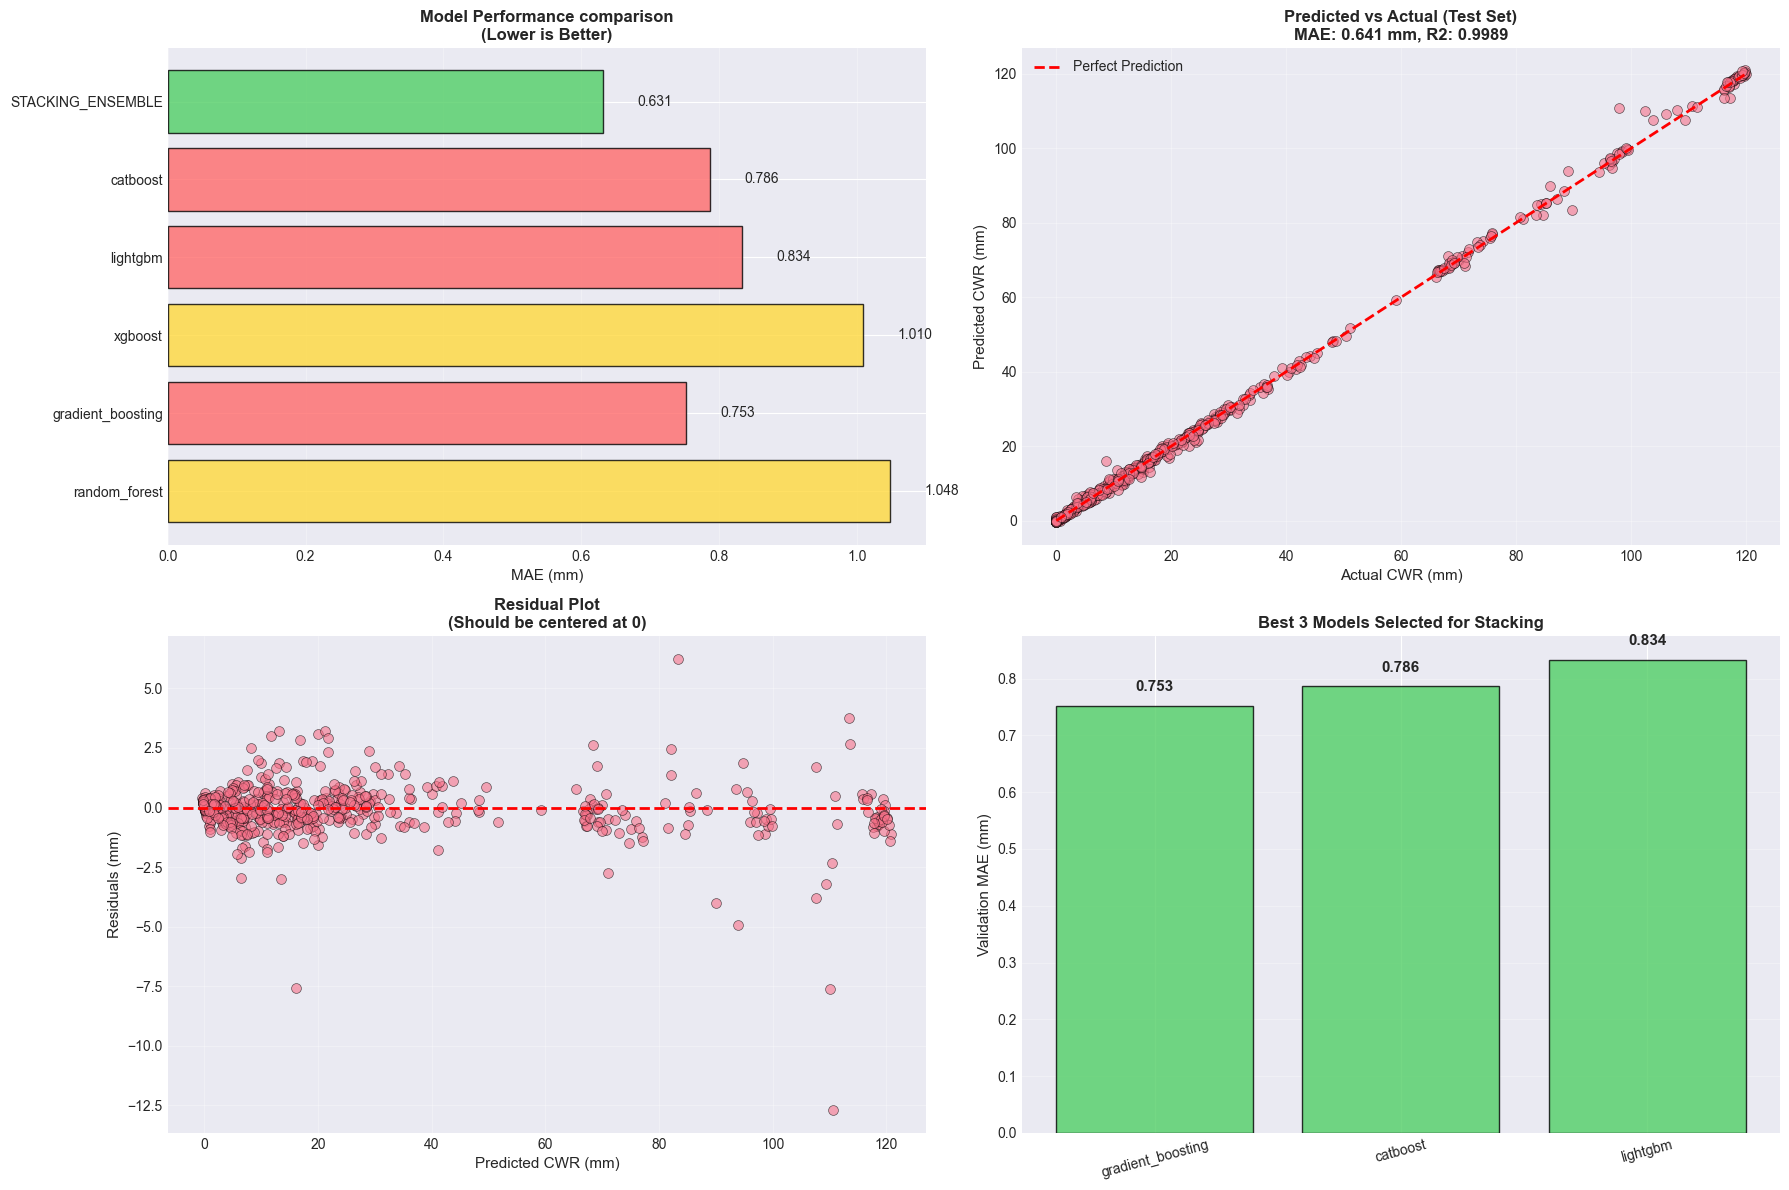


Stacking Ensemble analysis complete!
Results saved to: ./Visualisation/stacking_ensemble_results.png
Model saved to: ./Models/cwr_stacking_model.pkl
Model saved to: ./Models/cwr_random_forest_optimized.pkl
Model saved to: ./Models/cwr_gradient_boosting_optimized.pkl
Model saved to: ./Models/cwr_xgboost_optimized.pkl
Model saved to: ./Models/cwr_lightgbm_optimized.pkl
Model saved to: ./Models/cwr_catboost_optimized.pkl

Optimized hyperparameters saved for reference:

random_forest:
  n_estimators: 225
  max_depth: 22
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: None
  bootstrap: True

gradient_boosting:
  n_estimators: 232
  learning_rate: 0.119219575672799
  max_depth: 6
  min_samples_split: 7
  min_samples_leaf: 5

xgboost:
  n_estimators: 196
  max_depth: 5
  learning_rate: 0.19565396229312854
  subsample: 0.9053130396578273
  colsample_bytree: 0.8495459694315667

lightgbm:
  n_estimators: 202
  max_depth: 10
  learning_rate: 0.1120623700724927
  num_leaves: 24
  sub

In [22]:
# ============================================================================
# STEP 8: Visualize Results
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Model comparison (All 5 + Stacking)
ax1 = axes[0, 0]
models_list = list(model_scores.keys())
mae_values = [model_scores[m]['MAE'] for m in models_list]
colors = ['#51cf66' if m == 'STACKING_ENSEMBLE' else '#ff6b6b' if m in best_3_names else '#ffd93d' for m in models_list]

bars = ax1.barh(models_list, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('MAE (mm)', fontsize=11)
ax1.set_title('Model Performance comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, mae_values)):
    ax1.text(val + 0.05, i, f'{val:.3f}', va='center', fontsize=10)

# Plot 2: Predicted vs Actual (Test Set)
ax2 = axes[0, 1]
ax2.scatter(y_test, y_test_pred_stack, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual CWR (mm)', fontsize=11)
ax2.set_ylabel('Predicted CWR (mm)', fontsize=11)
ax2.set_title(f'Predicted vs Actual (Test Set)\nMAE: {test_metrics["MAE"]:.3f} mm, R2: {test_metrics["R2"]:.4f}',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Residuals
ax3 = axes[1, 0]
residuals = y_test - y_test_pred_stack
ax3.scatter(y_test_pred_stack, residuals, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Predicted CWR (mm)', fontsize=11)
ax3.set_ylabel('Residuals (mm)', fontsize=11)
ax3.set_title('Residual Plot\n(Should be centered at 0)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

# Plot 4: Best 3 Model Contributions
ax4 = axes[1, 1]
best_3_mae = [model_scores[name]['MAE'] for name in best_3_names]
bars = ax4.bar(best_3_names, best_3_mae, color='#51cf66', alpha=0.8, edgecolor='black')
ax4.set_ylabel('Validation MAE (mm)', fontsize=11)
ax4.set_title('Best 3 Models Selected for Stacking', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, best_3_mae):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./Visualisation/stacking_ensemble_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStacking Ensemble analysis complete!")
print(f"Results saved to: ./Visualisation/stacking_ensemble_results.png")

# Save stacking model
stacking_model_filename = './Models/cwr_stacking_model.pkl'
joblib.dump(stacking_model, stacking_model_filename)
print(f"Model saved to: {stacking_model_filename}")

# Save individual optimized models
for name, model in optimized_models.items():
    model_path = f'./Models/cwr_{name}_optimized.pkl'
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")

print("\nOptimized hyperparameters saved for reference:")
for name, params in optimized_params.items():
    print(f"\n{name}:")
    for param, value in params.items():
        print(f"  {param}: {value}")

# Explainable AI with SHAP

METHOD 3: EXPLAINABLE AI WITH SHAP (COMPREHENSIVE)

Four-level explainability analysis:
  1. Best base model (Gradient Boosting)
  2. All base models consensus
  3. True ensemble (KernelExplainer)
  4. Meta-learner contribution analysis

OPTION 1: SHAP Analysis on Gradient Boosting (Best Base Model)

STEP 1: Creating TreeExplainer for Gradient Boosting
----------------------------------------------------------------------
SHAP values calculated in 0.4 seconds
Shape: (600, 6) (samples x features)

Gradient Boosting Feature Importance:
              Feature  SHAP_Importance  GB_Feature_Importance
           Crop_Stage        13.889496               0.493535
       Water_Depth_cm        13.809229               0.239797
      Soil_Moisture_%        11.387509               0.206063
Rainfall_Predicted_mm         4.793674               0.034179
         Tank_Level_%         3.771668               0.025041
            ET_mm_day         0.707198               0.001385

Generating comprehensive 

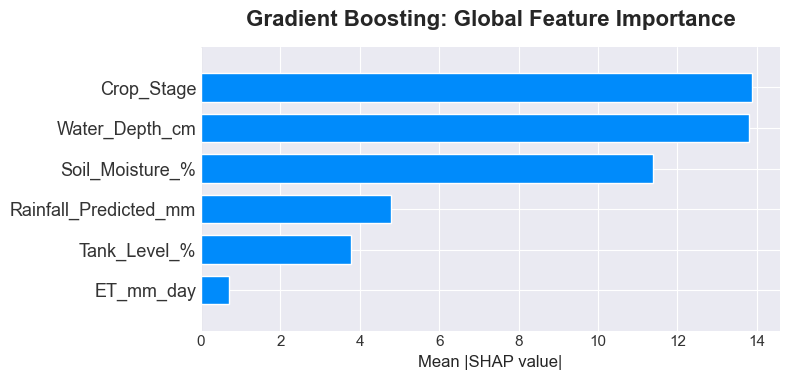

Creating Plot 2: Feature Impact Distribution...


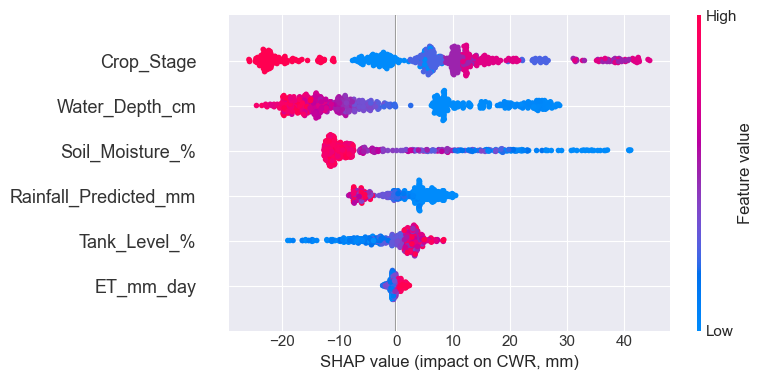

Creating Plot 3: Crop Stage Dependence...


<Figure size 800x600 with 0 Axes>

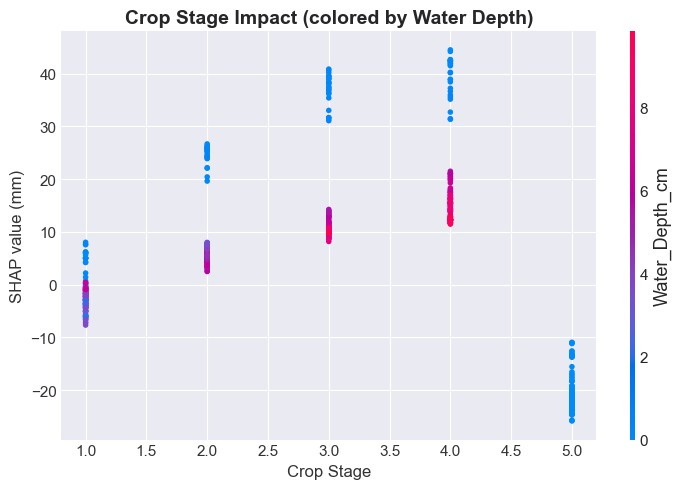

Creating Plot 4: Water Depth Dependence...


<Figure size 800x600 with 0 Axes>

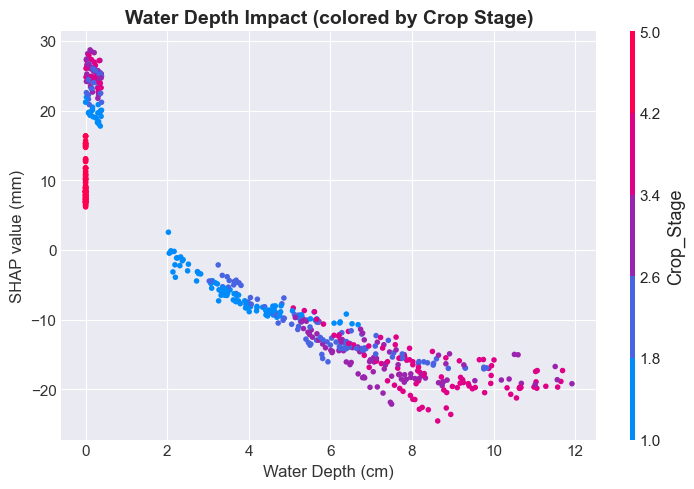

Creating Plot 5: ET Dependence...


<Figure size 800x600 with 0 Axes>

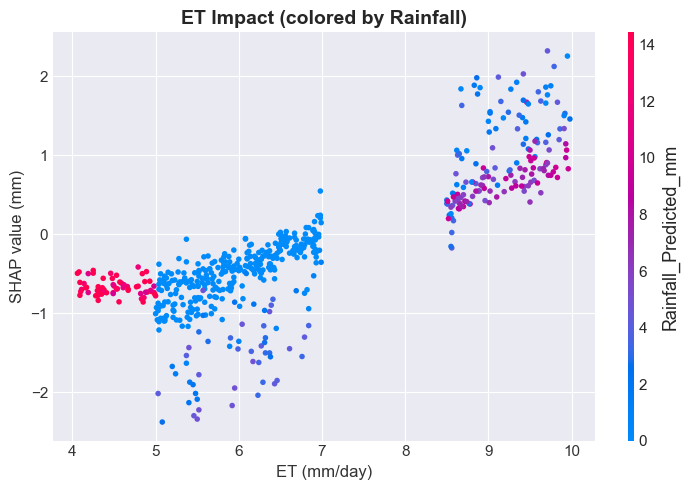

Creating Plot 6: Soil Moisture Dependence...


<Figure size 800x600 with 0 Axes>

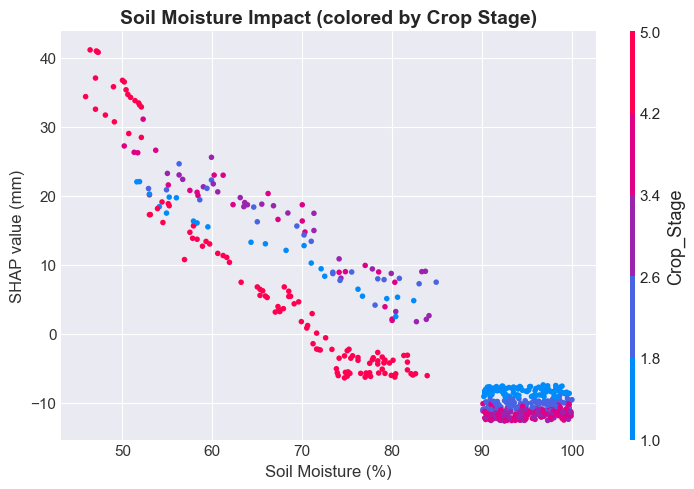


✓ Saved 6 separate SHAP plots:
  1. shap_1_feature_importance.png
  2. shap_2_beeswarm.png
  3. shap_3_crop_stage.png
  4. shap_4_water_depth.png
  5. shap_5_et.png
  6. shap_6_soil_moisture.png

Generating waterfall plots for sample predictions...


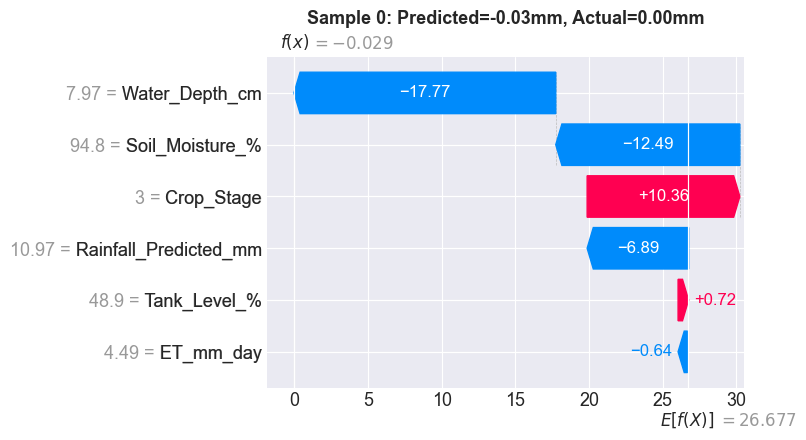

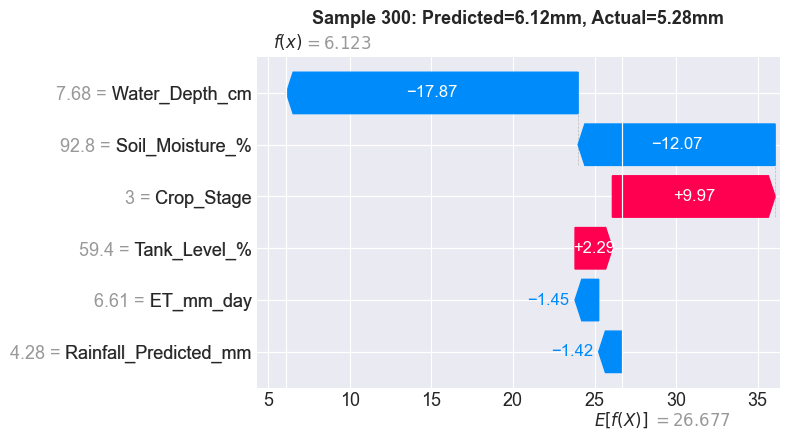

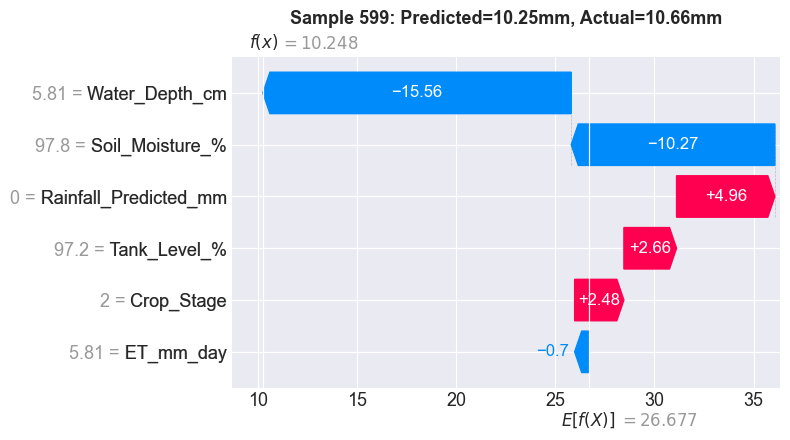


✓ Option 1 complete! Generated 9 clean, readable SHAP plots.


In [23]:
print("=" * 70)
print("METHOD 3: EXPLAINABLE AI WITH SHAP (COMPREHENSIVE)")
print("=" * 70)
print("\nFour-level explainability analysis:")
print("  1. Best base model (Gradient Boosting)")
print("  2. All base models consensus")
print("  3. True ensemble (KernelExplainer)")
print("  4. Meta-learner contribution analysis\n")

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

# ============================================================================
# OPTION 1: SHAP ON GRADIENT BOOSTING (BEST BASE MODEL)
# ============================================================================

print("=" * 70)
print("OPTION 1: SHAP Analysis on Gradient Boosting (Best Base Model)")
print("=" * 70)

print("\nSTEP 1: Creating TreeExplainer for Gradient Boosting")
print("-" * 70)

start_time = time.time()

# Get the best gradient boosting model
gb_model = optimized_models['gradient_boosting']

# Create explainer
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_test)

elapsed = time.time() - start_time
print(f"SHAP values calculated in {elapsed:.1f} seconds")
print(f"Shape: {shap_values_gb.shape} (samples x features)")

# Feature importance
feature_importance_gb = np.abs(shap_values_gb).mean(axis=0)
importance_df_gb = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': feature_importance_gb,
    'GB_Feature_Importance': gb_model.feature_importances_
}).sort_values('SHAP_Importance', ascending=False)

print("\nGradient Boosting Feature Importance:")
print(importance_df_gb.to_string(index=False))

# Comprehensive visualizations
print("\nGenerating comprehensive SHAP visualizations...")

# PLOT 1: Feature Importance Bar Chart
print("Creating Plot 1: Feature Importance...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gb, X_test, plot_type="bar", show=False)
plt.title('Gradient Boosting: Global Feature Importance', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_1_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 2: Summary Beeswarm Plot  
print("Creating Plot 2: Feature Impact Distribution...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gb, X_test, show=False)
plt.xlabel('SHAP value (impact on CWR, mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_2_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 3: Crop Stage Dependence
print("Creating Plot 3: Crop Stage Dependence...")
plt.figure(figsize=(8, 6))
shap.dependence_plot("Crop_Stage", shap_values_gb, X_test,
                     interaction_index="Water_Depth_cm", show=False)
plt.title('Crop Stage Impact (colored by Water Depth)', fontsize=14, fontweight='bold')
plt.xlabel('Crop Stage', fontsize=12)
plt.ylabel('SHAP value (mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_3_crop_stage.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 4: Water Depth Dependence
print("Creating Plot 4: Water Depth Dependence...")
plt.figure(figsize=(8, 6))
shap.dependence_plot("Water_Depth_cm", shap_values_gb, X_test,
                     interaction_index="Crop_Stage", show=False)
plt.title('Water Depth Impact (colored by Crop Stage)', fontsize=14, fontweight='bold')
plt.xlabel('Water Depth (cm)', fontsize=12)
plt.ylabel('SHAP value (mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_4_water_depth.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 5: ET Dependence
print("Creating Plot 5: ET Dependence...")
plt.figure(figsize=(8, 6))
shap.dependence_plot("ET_mm_day", shap_values_gb, X_test,
                     interaction_index="Rainfall_Predicted_mm", show=False)
plt.title('ET Impact (colored by Rainfall)', fontsize=14, fontweight='bold')
plt.xlabel('ET (mm/day)', fontsize=12)
plt.ylabel('SHAP value (mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_5_et.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 6: Soil Moisture Dependence
print("Creating Plot 6: Soil Moisture Dependence...")
plt.figure(figsize=(8, 6))
shap.dependence_plot("Soil_Moisture_%", shap_values_gb, X_test,
                     interaction_index="Crop_Stage", show=False)
plt.title('Soil Moisture Impact (colored by Crop Stage)', fontsize=14, fontweight='bold')
plt.xlabel('Soil Moisture (%)', fontsize=12)
plt.ylabel('SHAP value (mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_6_soil_moisture.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n✓ Saved 6 separate SHAP plots:")
print("  1. shap_1_feature_importance.png")
print("  2. shap_2_beeswarm.png")
print("  3. shap_3_crop_stage.png")
print("  4. shap_4_water_depth.png")
print("  5. shap_5_et.png")
print("  6. shap_6_soil_moisture.png")

# Individual prediction waterfall plots
print("\nGenerating waterfall plots for sample predictions...")
sample_indices = [0, len(X_test)//2, len(X_test)-1]

for idx in sample_indices:
    sample = X_test.iloc[idx]
    actual_cwr = y_test.iloc[idx]
    predicted_cwr = gb_model.predict(sample.values.reshape(1, -1))[0]
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_gb[idx],
            base_values=explainer_gb.expected_value,
            data=sample.values,
            feature_names=sample.index.tolist()
        ),
        show=False
    )
    plt.title(f'Sample {idx}: Predicted={predicted_cwr:.2f}mm, Actual={actual_cwr:.2f}mm',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./Visualisation/shap_waterfall_sample_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print("\n✓ Option 1 complete! Generated 9 clean, readable SHAP plots.")



OPTION 2: Cross-Model SHAP Consensus Analysis

Calculating SHAP values for all 3 base models...

Analyzing CatBoost...
Analyzing LightGBM...

Cross-Model Feature Importance Consensus:
              Feature   GB_SHAP  CatBoost_SHAP  LightGBM_SHAP  Average_SHAP  Std_Dev
           Crop_Stage 13.889496      11.017609      13.237195     12.714767 1.505534
       Water_Depth_cm 13.809229      13.860882       9.708895     12.459669 2.382380
      Soil_Moisture_% 11.387509       7.597596      14.743085     11.242730 3.574944
Rainfall_Predicted_mm  4.793674       7.052844       5.973475      5.939997 1.129957
         Tank_Level_%  3.771668       3.698548       3.795358      3.755191 0.050464
            ET_mm_day  0.707198       0.703605       0.869536      0.760113 0.094780


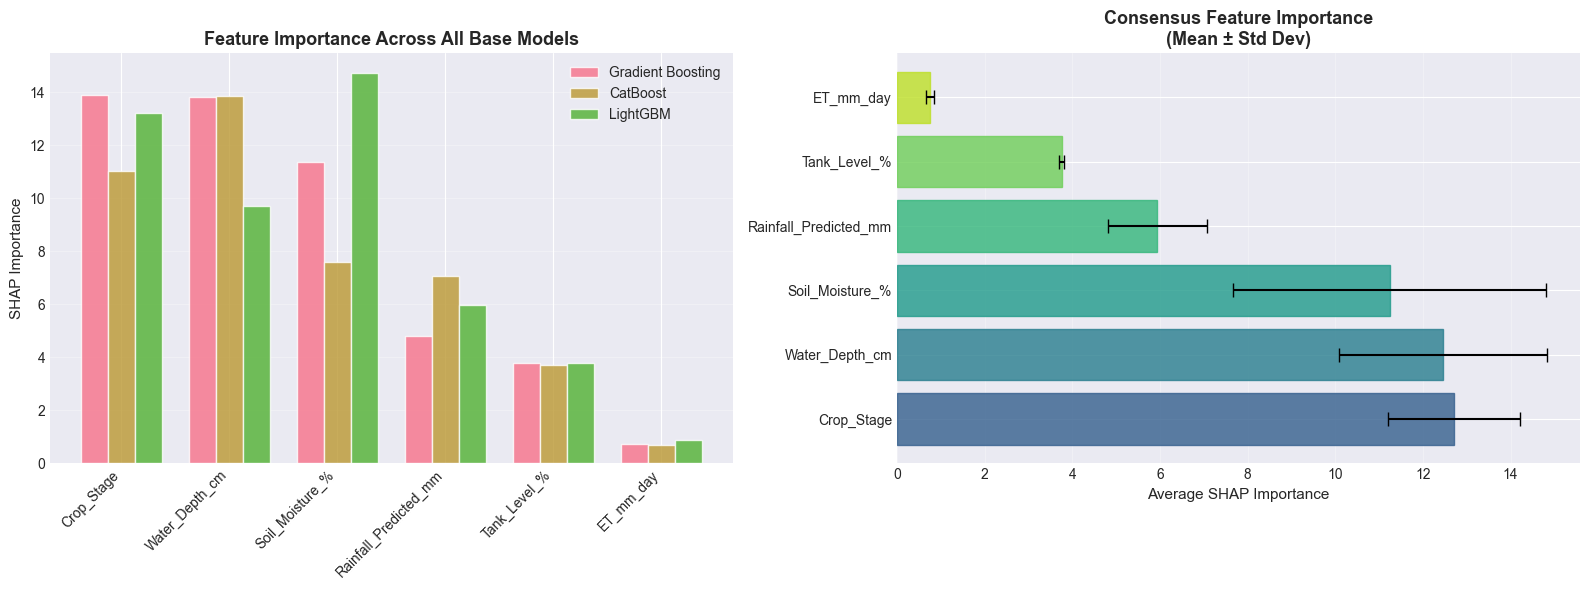

Saved: ./Visualisation/shap_option2_consensus.png
Option 2 complete!


In [24]:
# ============================================================================
# OPTION 2: SHAP ON ALL 3 BASE MODELS (CONSENSUS ANALYSIS)
# ============================================================================

print("\n" + "=" * 70)
print("OPTION 2: Cross-Model SHAP Consensus Analysis")
print("=" * 70)

print("\nCalculating SHAP values for all 3 base models...")

# CatBoost SHAP
print("\nAnalyzing CatBoost...")
cat_model = optimized_models['catboost']
explainer_cat = shap.TreeExplainer(cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)
feature_importance_cat = np.abs(shap_values_cat).mean(axis=0)

# LightGBM SHAP
print("Analyzing LightGBM...")
lgb_model = optimized_models['lightgbm']
explainer_lgb = shap.TreeExplainer(lgb_model)
shap_values_lgb = explainer_lgb.shap_values(X_test)
feature_importance_lgb = np.abs(shap_values_lgb).mean(axis=0)

# Consensus feature importance
consensus_df = pd.DataFrame({
    'Feature': X_test.columns,
    'GB_SHAP': feature_importance_gb,
    'CatBoost_SHAP': feature_importance_cat,
    'LightGBM_SHAP': feature_importance_lgb
})
consensus_df['Average_SHAP'] = consensus_df[['GB_SHAP', 'CatBoost_SHAP', 'LightGBM_SHAP']].mean(axis=1)
consensus_df['Std_Dev'] = consensus_df[['GB_SHAP', 'CatBoost_SHAP', 'LightGBM_SHAP']].std(axis=1)
consensus_df = consensus_df.sort_values('Average_SHAP', ascending=False)

print("\nCross-Model Feature Importance Consensus:")
print(consensus_df.to_string(index=False))

# Visualization: Consensus comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature importance comparison
ax1 = axes[0]
x_pos = np.arange(len(consensus_df))
width = 0.25

bars1 = ax1.bar(x_pos - width, consensus_df['GB_SHAP'], width, label='Gradient Boosting', alpha=0.8)
bars2 = ax1.bar(x_pos, consensus_df['CatBoost_SHAP'], width, label='CatBoost', alpha=0.8)
bars3 = ax1.bar(x_pos + width, consensus_df['LightGBM_SHAP'], width, label='LightGBM', alpha=0.8)

ax1.set_ylabel('SHAP Importance', fontsize=11)
ax1.set_title('Feature Importance Across All Base Models', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(consensus_df['Feature'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Average with error bars
ax2 = axes[1]
bars = ax2.barh(consensus_df['Feature'], consensus_df['Average_SHAP'], 
                xerr=consensus_df['Std_Dev'], alpha=0.8, edgecolor='black', capsize=5)
ax2.set_xlabel('Average SHAP Importance', fontsize=11)
ax2.set_title('Consensus Feature Importance\n(Mean ± Std Dev)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Color bars by importance
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig('./Visualisation/shap_option2_consensus.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ./Visualisation/shap_option2_consensus.png")
print("Option 2 complete!")


OPTION 3: True Ensemble Explainability (KernelExplainer)

This explains the ACTUAL stacking model predictions
(includes meta-learner contribution)
Initializing KernelExplainer...
Calculating SHAP values for stacking ensemble...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ KernelExplainer completed in 0.0 minutes

Stacking Ensemble Feature Importance (KernelExplainer):
              Feature  SHAP_Importance
       Water_Depth_cm        14.620902
           Crop_Stage        14.310992
      Soil_Moisture_%         8.888164
Rainfall_Predicted_mm         5.242342
         Tank_Level_%         3.080393
            ET_mm_day         0.598234

Creating Plot 1: Stacking Ensemble Feature Importance...


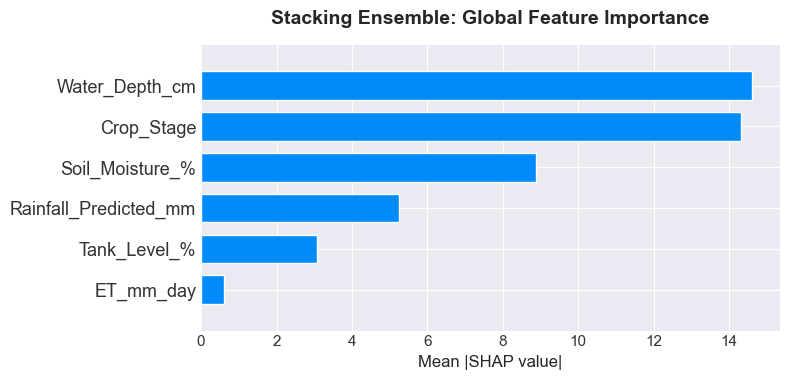

Creating Plot 2: Stacking Ensemble Impact Distribution...


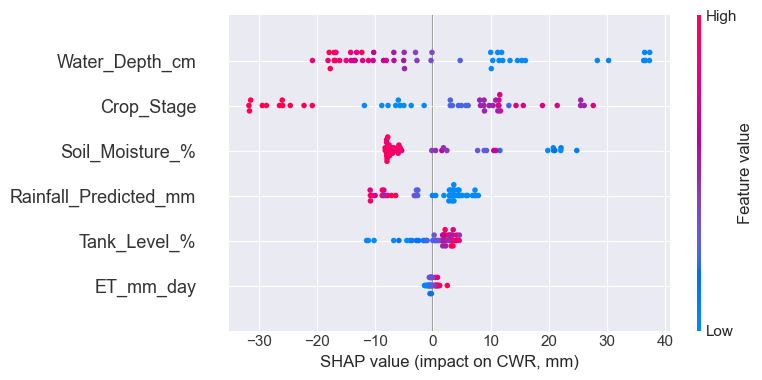


✓ Saved 2 separate plots:
  1. shap_option3_stacking_bar.png
  2. shap_option3_stacking_beeswarm.png

✓ Option 3 complete!


In [25]:
# ============================================================================
# OPTION 3: KERNEL EXPLAINER ON FULL STACKING ENSEMBLE
# ============================================================================

print("\n" + "=" * 70)
print("OPTION 3: True Ensemble Explainability (KernelExplainer)")
print("=" * 70)
print("\nThis explains the ACTUAL stacking model predictions")
print("(includes meta-learner contribution)")

start_time = time.time()

# Use subset of training data as background (for speed)
background_data = X_train.sample(n=100, random_state=42)

# Create KernelExplainer
print("Initializing KernelExplainer...")
explainer_stack = shap.KernelExplainer(stacking_model.predict, background_data)

# Calculate SHAP values (this is slow)
print("Calculating SHAP values for stacking ensemble...")

# Use smaller test set for speed (first 50 samples)
X_test_subset = X_test.head(50)
y_test_subset = y_test.head(50)

shap_values_stack = explainer_stack.shap_values(X_test_subset)

elapsed = time.time() - start_time
print(f"\n✓ KernelExplainer completed in {elapsed/60:.1f} minutes")

# Feature importance
feature_importance_stack = np.abs(shap_values_stack).mean(axis=0)
importance_df_stack = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': feature_importance_stack
}).sort_values('SHAP_Importance', ascending=False)

print("\n" + "=" * 70)
print("Stacking Ensemble Feature Importance (KernelExplainer):")
print("=" * 70)
print(importance_df_stack.to_string(index=False))

# ============================================================================
# FIXED: Create SEPARATE plots, not subplots!
# ============================================================================

# PLOT 1: Bar plot (separate figure)
print("\nCreating Plot 1: Stacking Ensemble Feature Importance...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_stack, X_test_subset, plot_type="bar", show=False)
plt.title('Stacking Ensemble: Global Feature Importance', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean |SHAP value|', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_option3_stacking_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# PLOT 2: Summary beeswarm plot (separate figure)
print("Creating Plot 2: Stacking Ensemble Impact Distribution...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_stack, X_test_subset, show=False)
plt.xlabel('SHAP value (impact on CWR, mm)', fontsize=12)
plt.tight_layout()
plt.savefig('./Visualisation/shap_option3_stacking_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n✓ Saved 2 separate plots:")
print("  1. shap_option3_stacking_bar.png")
print("  2. shap_option3_stacking_beeswarm.png")
print("\n✓ Option 3 complete!")



OPTION 4: Meta-Learner Analysis (Base Model Contributions)

Analyzing how Ridge meta-learner weights the 3 base models

Meta-Learner Ridge Coefficients:
  gradient_boosting: 0.5394
  catboost: 0.4151
  lightgbm: 0.0504
  Intercept: -0.0977

Base Model Contribution to Ensemble:
            Model  Coefficient  Abs_Coefficient  Percentage
gradient_boosting     0.539408         0.539408   53.681954
         catboost     0.415052         0.415052   41.306017
         lightgbm     0.050362         0.050362    5.012029

Base Model Prediction Correlation:
                   gradient_boosting  catboost  lightgbm
gradient_boosting           1.000000  0.998855  0.999346
catboost                    0.998855  1.000000  0.999049
lightgbm                    0.999346  0.999049  1.000000


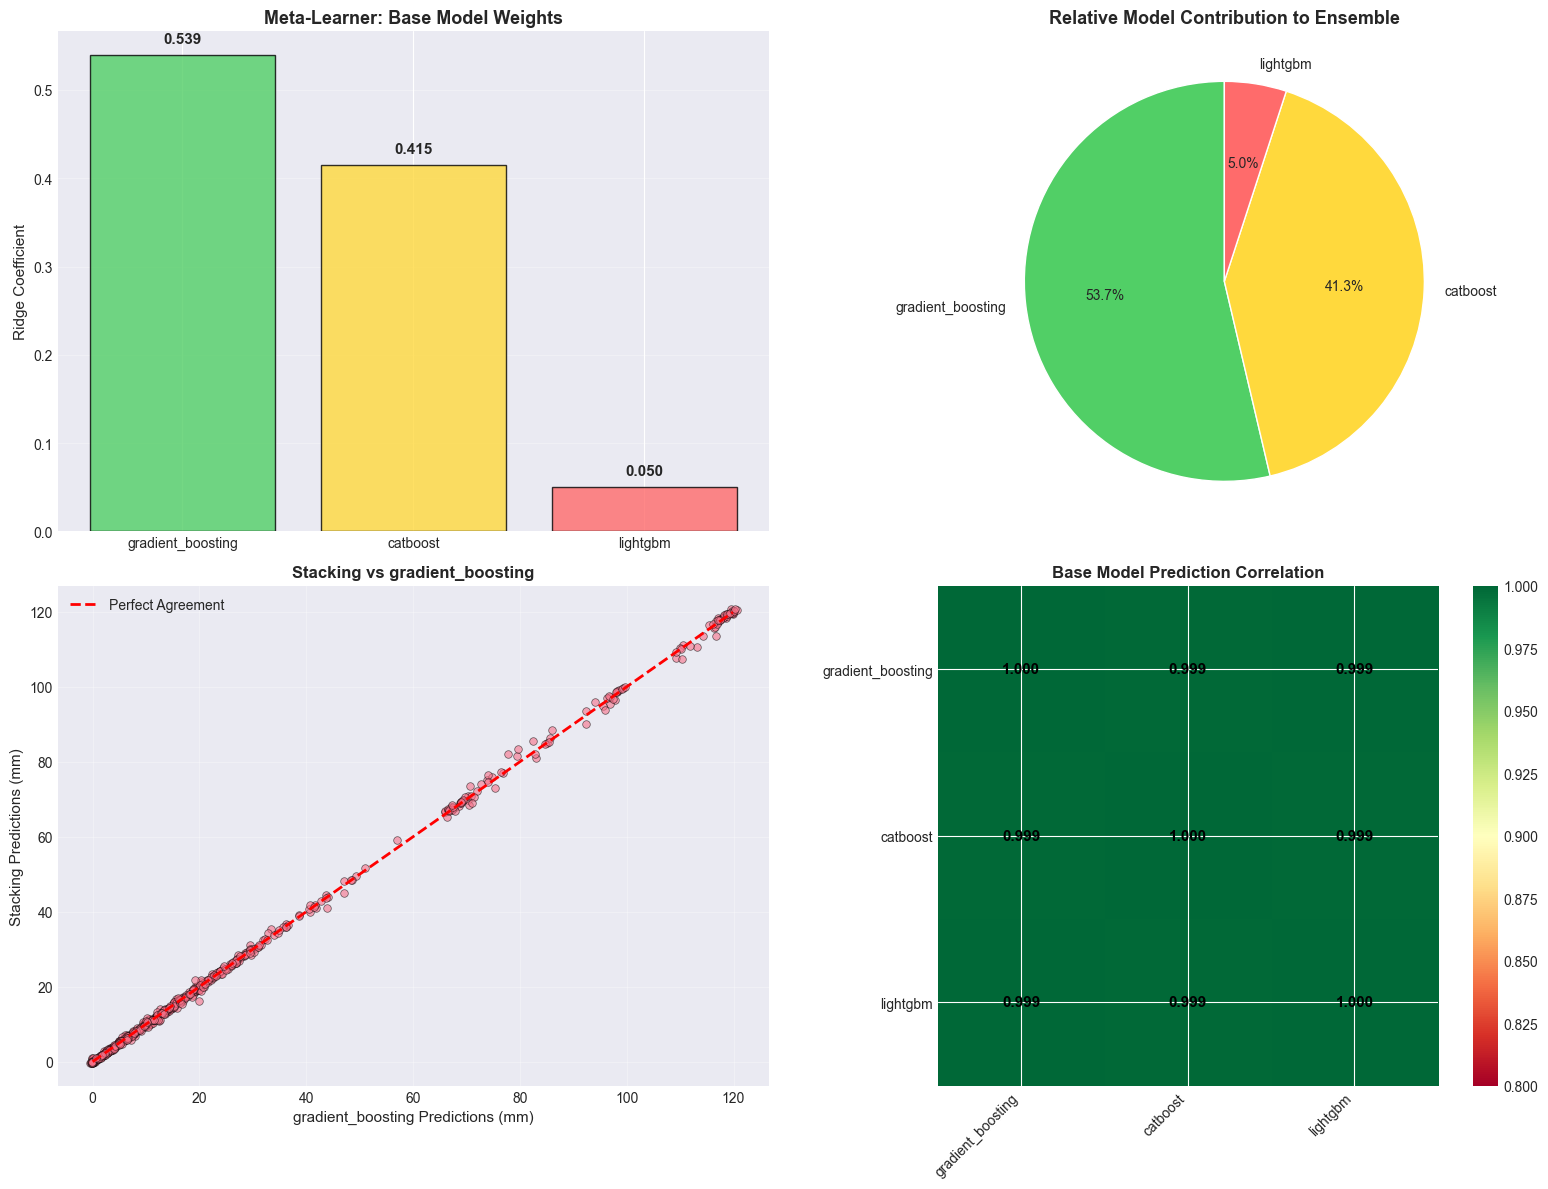

Saved: ./Visualisation/shap_option4_metalearner.png
Option 4 complete!


In [26]:
# ============================================================================
# OPTION 4: META-LEARNER CONTRIBUTION ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("OPTION 4: Meta-Learner Analysis (Base Model Contributions)")
print("=" * 70)
print("\nAnalyzing how Ridge meta-learner weights the 3 base models\n")

# Get base model predictions
base_predictions = {}
for name in best_3_names:
    model = optimized_models[name]
    base_predictions[name] = model.predict(X_test)

# Get stacking predictions
stacking_predictions = stacking_model.predict(X_test)

# Analyze meta-learner coefficients
meta_learner = stacking_model.final_estimator_
meta_coef = meta_learner.coef_

print("Meta-Learner Ridge Coefficients:")
for i, name in enumerate(best_3_names):
    print(f"  {name}: {meta_coef[i]:.4f}")

print(f"  Intercept: {meta_learner.intercept_:.4f}")

# Calculate base model contributions
contributions_df = pd.DataFrame({
    'Model': best_3_names,
    'Coefficient': meta_coef,
    'Abs_Coefficient': np.abs(meta_coef),
    'Percentage': (np.abs(meta_coef) / np.abs(meta_coef).sum()) * 100
}).sort_values('Abs_Coefficient', ascending=False)

print("\nBase Model Contribution to Ensemble:")
print(contributions_df.to_string(index=False))

# Prediction correlation analysis
correlation_matrix = pd.DataFrame(base_predictions).corr()
print("\nBase Model Prediction Correlation:")
print(correlation_matrix.to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Meta-learner coefficients
ax1 = axes[0, 0]
colors = ['#51cf66', '#ffd93d', '#ff6b6b']
bars = ax1.bar(contributions_df['Model'], contributions_df['Coefficient'], 
               color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Ridge Coefficient', fontsize=11)
ax1.set_title('Meta-Learner: Base Model Weights', fontsize=13, fontweight='bold')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, contributions_df['Coefficient']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Percentage contribution
ax2 = axes[0, 1]
wedges, texts, autotexts = ax2.pie(contributions_df['Percentage'], 
                                     labels=contributions_df['Model'],
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90)
ax2.set_title('Relative Model Contribution to Ensemble', fontsize=13, fontweight='bold')

# Plot 3: Prediction scatter (GB vs Stacking)
ax3 = axes[1, 0]
ax3.scatter(base_predictions[best_3_names[0]], stacking_predictions, 
            alpha=0.6, s=30, edgecolor='black', linewidth=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Agreement')
ax3.set_xlabel(f'{best_3_names[0]} Predictions (mm)', fontsize=11)
ax3.set_ylabel('Stacking Predictions (mm)', fontsize=11)
ax3.set_title(f'Stacking vs {best_3_names[0]}', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Correlation heatmap
ax4 = axes[1, 1]
im = ax4.imshow(correlation_matrix, cmap='RdYlGn', vmin=0.8, vmax=1.0)
ax4.set_xticks(np.arange(len(best_3_names)))
ax4.set_yticks(np.arange(len(best_3_names)))
ax4.set_xticklabels(best_3_names, rotation=45, ha='right')
ax4.set_yticklabels(best_3_names)
ax4.set_title('Base Model Prediction Correlation', fontsize=12, fontweight='bold')

for i in range(len(best_3_names)):
    for j in range(len(best_3_names)):
        text = ax4.text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=11, fontweight='bold')

plt.colorbar(im, ax=ax4)
plt.tight_layout()
plt.savefig('./Visualisation/shap_option4_metalearner.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ./Visualisation/shap_option4_metalearner.png")
print("Option 4 complete!")

In [27]:
# ============================================================================
# CWR PREDICTION USING SAVED STACKING ENSEMBLE MODEL
# ============================================================================

import pickle
import numpy as np
import pandas as pd

# ============================================================================
# STEP 1: LOAD THE SAVED STACKING MODEL
# ============================================================================

print("=" * 60)
print("CWR PREDICTION - STACKING ENSEMBLE MODEL")
print("=" * 60)

import joblib

stacking_model_filename = './Models/cwr_stacking_model.pkl'

print(f"Loading model from: {stacking_model_filename}")

loaded_stacking_model = joblib.load(stacking_model_filename)

print("✓ Model loaded successfully!")
print(f"  Base models: gradient_boosting, catboost, lightgbm")
print(f"  Meta-learner: Ridge")

# ============================================================================
# STEP 2: DEFINE EXAMPLE INPUTS
# ============================================================================

print("\n" + "=" * 60)
print("EXAMPLE PREDICTION SCENARIOS")
print("=" * 60)

# Feature names (must match training order exactly!)
feature_names = [
    'Water_Depth_cm',
    'Soil_Moisture_%',
    'Tank_Level_%',
    'ET_mm_day',
    'Rainfall_Predicted_mm',
    'Crop_Stage'
]

# Define 5 realistic scenarios
scenarios = {
    'Stage 1 - Normal Seedling': {
        'Water_Depth_cm': 3.5,
        'Soil_Moisture_%': 95.0,
        'Tank_Level_%': 70.0,
        'ET_mm_day': 6.0,
        'Rainfall_Predicted_mm': 0.0,
        'Crop_Stage': 1
    },
    'Stage 2 - Dried Tillering Field': {
        'Water_Depth_cm': 0.2,
        'Soil_Moisture_%': 55.0,
        'Tank_Level_%': 80.0,
        'ET_mm_day': 7.0,
        'Rainfall_Predicted_mm': 0.0,
        'Crop_Stage': 2
    },
    'Stage 3 - High ET Vegetative': {
        'Water_Depth_cm': 5.5,
        'Soil_Moisture_%': 93.0,
        'Tank_Level_%': 65.0,
        'ET_mm_day': 9.0,
        'Rainfall_Predicted_mm': 0.0,
        'Crop_Stage': 3
    },
    'Stage 4 - Critical Reproductive': {
        'Water_Depth_cm': 1.2,
        'Soil_Moisture_%': 75.0,
        'Tank_Level_%': 75.0,
        'ET_mm_day': 7.0,
        'Rainfall_Predicted_mm': 0.0,
        'Crop_Stage': 4
    },
    'Stage 4 - Rain Expected': {
        'Water_Depth_cm': 9.0,
        'Soil_Moisture_%': 96.0,
        'Tank_Level_%': 75.0,
        'ET_mm_day': 6.0,
        'Rainfall_Predicted_mm': 12.0,
        'Crop_Stage': 4
    },
    'Stage 5 - Dry Ripening': {
        'Water_Depth_cm': 0.0,
        'Soil_Moisture_%': 48.0,
        'Tank_Level_%': 65.0,
        'ET_mm_day': 5.0,
        'Rainfall_Predicted_mm': 0.0,
        'Crop_Stage': 5
    }
}

# Stage names for display
stage_names = {
    1: 'Seedling',
    2: 'Tillering',
    3: 'Vegetative',
    4: 'Reproductive',
    5: 'Ripening'
}

# ============================================================================
# STEP 3: PREDICT CWR FOR EACH SCENARIO
# ============================================================================

print("\nRunning predictions...\n")

results = []

for scenario_name, inputs in scenarios.items():
    
    # Convert inputs to DataFrame (preserves feature names)
    input_df = pd.DataFrame([inputs], columns=feature_names)
    
    # Predict CWR
    predicted_cwr = loaded_stacking_model.predict(input_df)[0]
    predicted_cwr = max(0, round(predicted_cwr, 2))
    
    # Store result
    results.append({
        'Scenario': scenario_name,
        'Inputs': inputs,
        'Predicted_CWR_mm': predicted_cwr
    })

# ============================================================================
# STEP 4: DISPLAY RESULTS CLEARLY
# ============================================================================

for i, result in enumerate(results, 1):
    inputs = result['Inputs']
    cwr = result['Predicted_CWR_mm']
    stage = int(inputs['Crop_Stage'])
    
    print("─" * 60)
    print(f"Scenario {i}: {result['Scenario']}")
    print("─" * 60)
    print(f"  Input Features:")
    print(f"    Water Depth:        {inputs['Water_Depth_cm']} cm")
    print(f"    Soil Moisture:      {inputs['Soil_Moisture_%']} %")
    print(f"    Tank Level:         {inputs['Tank_Level_%']} %")
    print(f"    ET:                 {inputs['ET_mm_day']} mm/day")
    print(f"    Rainfall (24hr):    {inputs['Rainfall_Predicted_mm']} mm")
    print(f"    Crop Stage:         {stage} ({stage_names[stage]})")
    print(f"\n  ➤ Predicted CWR:     {cwr} mm")
    
    # Irrigation decision interpretation
    if cwr == 0:
        decision = "⛔ No irrigation needed"
        reason = "Rain expected or field already adequate"
    elif cwr < 10:
        decision = "🟡 Low irrigation needed"
        reason = "Minor deficit, small top-up required"
    elif cwr < 25:
        decision = "🟠 Moderate irrigation needed"
        reason = "Noticeable deficit, standard irrigation"
    elif cwr < 45:
        decision = "🔴 High irrigation needed"
        reason = "Significant deficit, urgent irrigation"
    else:
        decision = "🚨 Critical irrigation needed"
        reason = "Severe deficit, maximum irrigation event"
    
    print(f"  ➤ Decision:          {decision}")
    print(f"  ➤ Reason:            {reason}\n")

# ============================================================================
# STEP 5: SUMMARY TABLE
# ============================================================================

print("=" * 60)
print("PREDICTION SUMMARY")
print("=" * 60)

print(f"\n{'No.':<4} {'Scenario':<35} {'CWR (mm)':<12} {'Action'}")
print("─" * 80)

for i, result in enumerate(results, 1):
    cwr = result['Predicted_CWR_mm']
    name = result['Scenario'][:34]
    
    if cwr == 0:
        action = "Skip"
    elif cwr < 10:
        action = "Low"
    elif cwr < 25:
        action = "Moderate"
    elif cwr < 45:
        action = "High"
    else:
        action = "Critical"
    
    print(f"{i:<4} {name:<35} {cwr:<12} {action}")

print("\n" + "=" * 60)
print("✓ All predictions complete!")
print(f"  Model: Stacking Ensemble (GB + CatBoost + LightGBM)")
print(f"  Meta-Learner: Ridge Regression")
print(f"  Expected MAE: ~1.478mm")
print("=" * 60)

# ============================================================================
# STEP 6: SINGLE CUSTOM PREDICTION FUNCTION (USE ANYTIME)
# ============================================================================

def predict_cwr(water_depth_cm, soil_moisture_pct, tank_level_pct,
                ET_mm_day, rainfall_mm, crop_stage):
    """
    Predict CWR for a single set of sensor readings.
    
    Parameters:
    -----------
    water_depth_cm      : float - Standing water depth (cm)
    soil_moisture_pct   : float - Soil moisture (%)
    tank_level_pct      : float - Tank water level (%)
    ET_mm_day           : float - Evapotranspiration (mm/day)
    rainfall_mm         : float - Predicted rainfall next 24hr (mm)
    crop_stage          : int   - Crop stage (1=Seedling to 5=Ripening)
    
    Returns:
    --------
    float : Predicted CWR in mm
    """
    input_data = pd.DataFrame([{
        'Water_Depth_cm': water_depth_cm,
        'Soil_Moisture_%': soil_moisture_pct,
        'Tank_Level_%': tank_level_pct,
        'ET_mm_day': ET_mm_day,
        'Rainfall_Predicted_mm': rainfall_mm,
        'Crop_Stage': crop_stage
    }])
    
    cwr = loaded_stacking_model.predict(input_data)[0]
    return max(0, round(cwr, 2))


# Example usage of single prediction function
print("\n" + "=" * 60)
print("CUSTOM SINGLE PREDICTION EXAMPLE")
print("=" * 60)

custom_cwr = predict_cwr(
    water_depth_cm=4.0,
    soil_moisture_pct=92.0,
    tank_level_pct=55.0,
    ET_mm_day=6.5,
    rainfall_mm=2.0,
    crop_stage=3
)

print(f"\nCustom Input:")
print(f"  Water Depth: 4.0 cm | Soil Moisture: 92.0%")
print(f"  Tank Level: 55.0% | ET: 6.5 mm/day")
print(f"  Rainfall: 2.0 mm | Stage: 3 (Vegetative)")
print(f"\n  ➤ Predicted CWR: {custom_cwr} mm")
print("\n✓ Use predict_cwr() function anytime for live sensor readings!")
print("=" * 60)


CWR PREDICTION - STACKING ENSEMBLE MODEL
Loading model from: ./Models/cwr_stacking_model.pkl
✓ Model loaded successfully!
  Base models: gradient_boosting, catboost, lightgbm
  Meta-learner: Ridge

EXAMPLE PREDICTION SCENARIOS

Running predictions...

────────────────────────────────────────────────────────────
Scenario 1: Stage 1 - Normal Seedling
────────────────────────────────────────────────────────────
  Input Features:
    Water Depth:        3.5 cm
    Soil Moisture:      95.0 %
    Tank Level:         70.0 %
    ET:                 6.0 mm/day
    Rainfall (24hr):    0.0 mm
    Crop Stage:         1 (Seedling)

  ➤ Predicted CWR:     14.32 mm
  ➤ Decision:          🟠 Moderate irrigation needed
  ➤ Reason:            Noticeable deficit, standard irrigation

────────────────────────────────────────────────────────────
Scenario 2: Stage 2 - Dried Tillering Field
────────────────────────────────────────────────────────────
  Input Features:
    Water Depth:        0.2 cm
    Soil M

In [28]:
# Run this to check
from sklearn.model_selection import cross_val_score

for name, model in optimized_models.items():
    train_score = model.score(X_train, y_train)
    val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    print(f"{name}:")
    print(f"  Train R²:      {train_score:.4f}")
    print(f"  Val R² (mean): {val_scores.mean():.4f}")
    print(f"  Gap:           {train_score - val_scores.mean():.4f}")
    print(f"  Overfit?       {'YES ⚠️' if train_score - val_scores.mean() > 0.01 else 'NO ✓'}")


random_forest:
  Train R²:      0.9996
  Val R² (mean): 0.9965
  Gap:           0.0031
  Overfit?       NO ✓
gradient_boosting:
  Train R²:      0.9999
  Val R² (mean): 0.9981
  Gap:           0.0018
  Overfit?       NO ✓
xgboost:
  Train R²:      0.9998
  Val R² (mean): 0.9962
  Gap:           0.0037
  Overfit?       NO ✓
lightgbm:
  Train R²:      0.9995
  Val R² (mean): 0.9965
  Gap:           0.0030
  Overfit?       NO ✓
catboost:
  Train R²:      0.9998
  Val R² (mean): 0.9976
  Gap:           0.0022
  Overfit?       NO ✓
